Train word2vec/GloVe on a small corpus; visualize
neighborhoods; intrinsic vs. extrinsic evaluation.

In [16]:
import re
from typing import List, Callable, Any, Dict
from datasets import load_dataset
from functorch.dim import softmax
from gensim.models import Word2Vec, KeyedVectors
from sklearn.metrics import f1_score, recall_score, precision_score
import gensim.downloader as api
import numpy as np
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression

Download dataset **ag_news**:

In [17]:
dataset = load_dataset("ag_news")

Select train & text:

In [18]:
train_text = dataset["train"]
test_text = dataset["test"]

Sample example:

we have text with new's title and description, and one of four labels

In [19]:
train_text[634]

{'text': 'Dodgers Rally in 8th to Defeat Cubs 8-5 (AP) AP - Adrian Beltre and Shawn Green homered, and Steve Finley hit a go-ahead RBI single in the eighth inning as the Los Angeles Dodgers rallied for an 8-5 victory over the Chicago Cubs on Sunday.',
 'label': 1}

Tokenize all train text:

In [20]:
def tokenize(text: str, pattern: str = None) -> List[str]:
    pattern = r"(?:\w+')\w+|(?:[A-Z]\.)+|\w+(?:-\w+)*|[\w+\.]"
    tokens = re.findall(pattern, text)
    return tokens

Tokenize train and test tokens

In [21]:
train_tokens = [tokenize(text_sample) for text_sample in list(train_text["text"])]
test_tokens = [tokenize(text_sample) for text_sample in list(test_text["text"])]

And get all tokens for training

In [22]:
all_tokens = train_tokens + test_tokens

First, we will train our model on **all corpus of text**:

Create Word2Vec model

In [23]:
model_w2v_locally_train_all_dataset = Word2Vec(
    vector_size=300,
    window=4,
    min_count=1,
    sg=1,
    epochs=2000,
    seed=42,
    workers=12,
    negative=6,
)
model_w2v_locally_train_all_dataset.build_vocab(all_tokens)

Train our Word2Vec model:

In [24]:
model_w2v_locally_train_all_dataset.train(
    corpus_iterable=all_tokens,
    total_examples=len(all_tokens),
    epochs=3,

) # (849832055, 1030897600) 10m

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


(12748366, 15463464)

Now let's create an PCA:

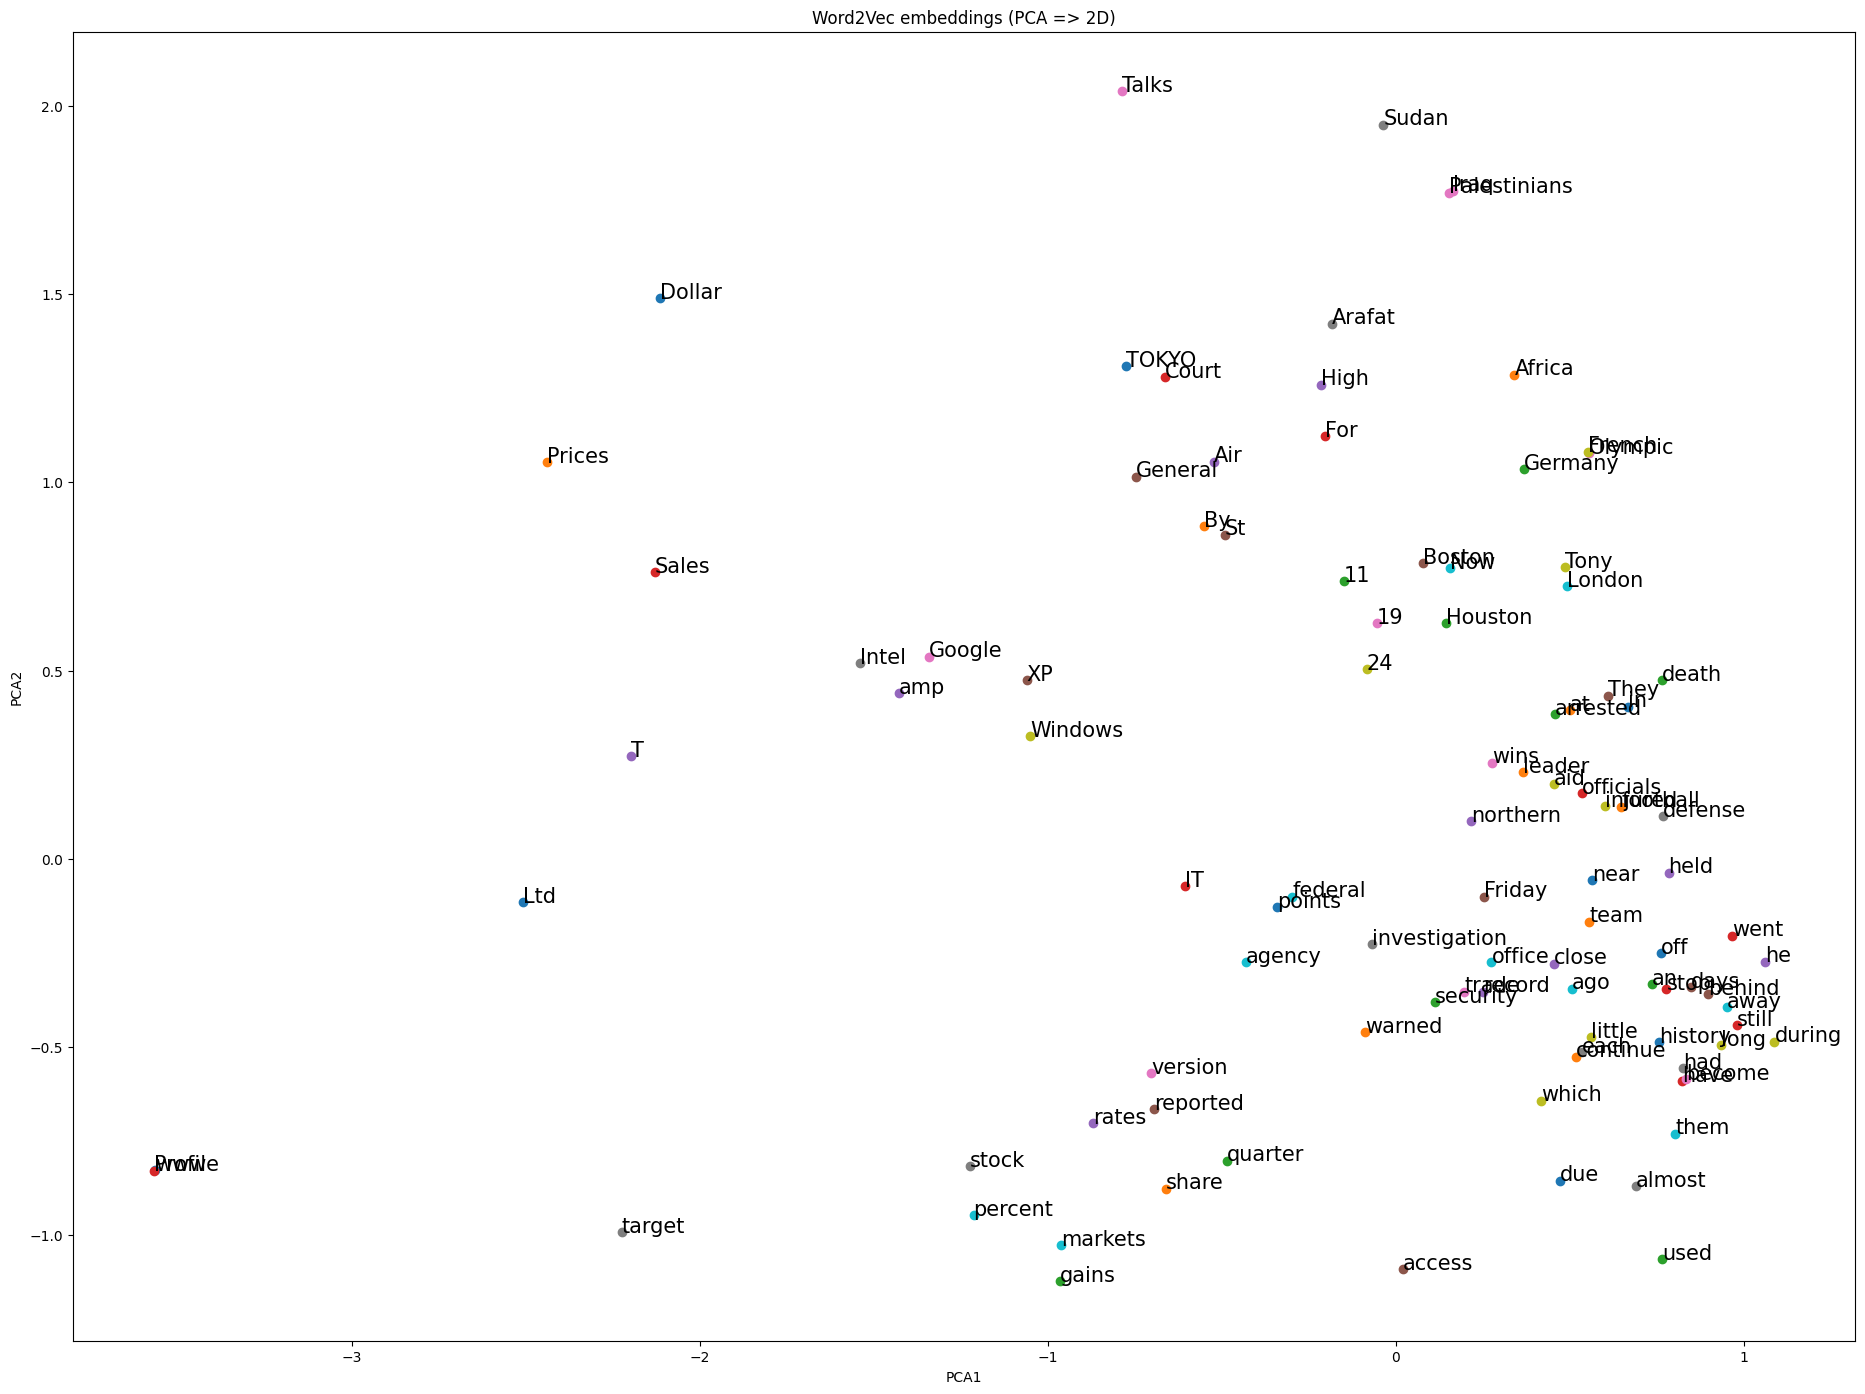

In [25]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

words = list(model_w2v_locally_train_all_dataset.wv.key_to_index.keys())[:1000]
vectors = model_w2v_locally_train_all_dataset.wv[words]

pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

plt.figure(figsize=(23, 17))
for i, word in enumerate(words):
    if i % 10 == 5:
        plt.scatter(coords[i, 0], coords[i, 1])
        plt.annotate(word, (coords[i, 0], coords[i, 1]), fontsize=15)
plt.title("Word2Vec embeddings (PCA => 2D)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

## Intrinsic evaluation

In [26]:
model_w2v_locally_train_all_dataset.wv.most_similar("football", topn=10)

[('college', 0.8030233979225159),
 ('coaching', 0.7849875092506409),
 ('basketball', 0.7729490399360657),
 ('coaches', 0.7576501369476318),
 ('Willingham', 0.73418790102005),
 ('vacancy', 0.7327612638473511),
 ('soccer', 0.7325695753097534),
 ('Tyrone', 0.72718346118927),
 ("school's", 0.7215853929519653),
 ('Nebraska', 0.7206881046295166)]

In [27]:
model_w2v_locally_train_all_dataset.wv.most_similar(positive=["university"], negative=["school"])

[('Solutions', 0.4005904197692871),
 ('Personal', 0.3937704265117645),
 ('Parcel', 0.3915112018585205),
 ('Federated', 0.3895711302757263),
 ('US-based', 0.38676121830940247),
 ('Homeland', 0.38469383120536804),
 ('WebEx', 0.38147011399269104),
 ('department', 0.3787011206150055),
 ('upgraded', 0.37850654125213623),
 ('consultant', 0.3774315416812897)]

## Extrinsic evaluation

For extrinsic evaluation we can build a simple logistic regression to classify new's topic.

For do this, we will use pool method to create embeddings of sentence.

In [28]:
def text_to_vector(tokens, model):
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

In [29]:
X_train = np.array([text_to_vector(s, model_w2v_locally_train_all_dataset) for s in train_tokens])
X_test = np.array([text_to_vector(s, model_w2v_locally_train_all_dataset) for s in test_tokens])

y_train = train_text["label"]
y_test = test_text["label"]

lg_r_model = LogisticRegression(max_iter=1000)
lg_r_model.fit(X_train, y_train)

predictions = lg_r_model.predict(X_test)

In [30]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.90      0.89      0.90      1900
           1       0.95      0.97      0.96      1900
           2       0.85      0.85      0.85      1900
           3       0.86      0.86      0.86      1900

    accuracy                           0.89      7600
   macro avg       0.89      0.89      0.89      7600
weighted avg       0.89      0.89      0.89      7600

